<div style='text-align: center;'>
<img src="images/math60082-banner.png" alt="image" width="80%" height="auto">
</div>

# Lab Workbook - Week 7


In [1]:
import matplotlib.pyplot as plt
import math
import numpy

Matplotlib is building the font cache; this may take a moment.


In [2]:
# stock parameters
S_0 = 100 # initial stick price

# call option contract parameters
X = 100 # strike price
T = 1.0 # time to expiry

# market parameters
r = 0.06 # risk-free interest rate

# model parameters
sigma = 0.2 #  volatility

# steps in the tree
n=3

# local stuff
dt = T/n
u = numpy.exp(sigma*numpy.sqrt(dt))
d = 1./u
q = (numpy.exp(r*dt) - d)/(u-d)
print("dt=",dt,";u=",u,";d=",d,";q=",q)

dt= 0.3333333333333333 ;u= 1.1224009024456676 ;d= 0.8909472522884107 ;q= 0.5584448015856557


In [3]:
stock_tree = numpy.zeros(shape=(n+1,n+1))
stock_tree

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [4]:

for i in range(0,n+1):
    for j in range(0,i+1):
        stock_tree[i][j] = S_0*pow(u,j)*pow(d,i-j)
stock_tree

array([[100.        ,   0.        ,   0.        ,   0.        ],
       [ 89.09472523, 112.24009024,   0.        ,   0.        ],
       [ 79.37870064, 100.        , 125.97837858,   0.        ],
       [ 70.72223522,  89.09472523, 112.24009024, 141.39824581]])

In [5]:
value_tree = numpy.zeros(shape=(n+1,n+1))

In [6]:
for j in range(0,n+1):
    value_tree[n][j] = max( stock_tree[n][j] - X , 0.0)

# Tasks


1. Write `for` loops to move backwards through the vector array calculating the value of the option at each node.


In [7]:
for i in range(n-1,-1,-1):
    for j in range(i+1):
        value_tree[i][j] = numpy.exp(-r*dt)*( q*value_tree[i+1][j+1] + (1-q)*value_tree[i+1][j] )

2. Print out the tree to screen (with $n=3$) and compare to the simple example from the notes to check your code is working.


In [8]:
print(value_tree)

[[11.55197318  0.          0.          0.        ]
 [ 3.66752722 18.20398861  0.          0.        ]
 [ 0.          6.70006449 27.95851125  0.        ]
 [ 0.          0.         12.24009024 41.39824581]]


3. If your values don't match - try to work out why!!


In [9]:
print("It works!!")

It works!!


4. Now print out the value at $(0,0)$ increasing the number of steps in the tree. Do the results look feasible? Compare them against the exact values from the formula.


In [10]:
def blackScholesCall(S,t,X,T,r,sigma):
    d1 = ( numpy.log(S/X) + (r+0.5*sigma*sigma)*(T-t) ) / (sigma*numpy.sqrt(T-t))
    d2 = ( numpy.log(S/X) + (r-0.5*sigma*sigma)*(T-t) ) / (sigma*numpy.sqrt(T-t))
    N = lambda x: 0.5 * (1.0 + math.erf(x / numpy.sqrt(2)))

    return S * N(d1) - X * numpy.exp(-r * (T-t)) * N(d2)
     

In [11]:
# stock parameters
S_0 = 100 # initial stick price

# call option contract parameters
X = 100 # strike price
T = 1.0 # time to expiry

# market parameters
r = 0.06 # risk-free interest rate

# model parameters
sigma = 0.2 #  volatility

for n in range(10,100):
    # local stuff
    dt = T/n
    u = numpy.exp(sigma*numpy.sqrt(dt))
    d = 1./u
    q = (numpy.exp(r*dt) - d)/(u-d)

    stock_tree = numpy.zeros(shape=(n+1,n+1))
    value_tree = numpy.zeros(shape=(n+1,n+1))

    for i in range(0,n+1):
        for j in range(0,i+1):
            stock_tree[i][j] = S_0*pow(u,j)*pow(d,i-j)
            
    for j in range(0,n+1):
        value_tree[n][j] = max( stock_tree[n][j] - X , 0.0)
        
    for i in range(n-1,-1,-1):
        for j in range(i+1):
            value_tree[i][j] = numpy.exp(-r*dt)*( q*value_tree[i+1][j+1] + (1-q)*value_tree[i+1][j] )

    print(n,value_tree[0][0] , " :: ",blackScholesCall(S_0,0,X,T,r,sigma))


10 10.791042370630098  ::  10.989549152625983
11 11.142379849834876  ::  10.989549152625983
12 10.823702249656305  ::  10.989549152625983
13 11.11875706565201  ::  10.989549152625983
14 10.847141495142642  ::  10.989549152625983
15 11.101453722123585  ::  10.989549152625983
16 10.86477963742096  ::  10.989549152625983
17 11.088234683498005  ::  10.989549152625983
18 10.878532136464607  ::  10.989549152625983
19 11.077807212966208  ::  10.989549152625983
20 10.889555099630222  ::  10.989549152625983
21 11.069371847937811  ::  10.989549152625983
22 10.89858752313821  ::  10.989549152625983
23 11.062407691810915  ::  10.989549152625983
24 10.90612378949058  ::  10.989549152625983
25 11.05656084095637  ::  10.989549152625983
26 10.912507119981957  ::  10.989549152625983
27 11.051582447012496  ::  10.989549152625983
28 10.917983233791059  ::  10.989549152625983
29 11.047292436764073  ::  10.989549152625983
30 10.922732668892145  ::  10.989549152625983
31 11.04355729271652  ::  10.9895491526

5. Create a function returning the value of the binomial tree for a set of given parameters.


In [12]:
def binomialBlackScholes(S_0,T,r,sigma,payoff,n):
    # setup
    dt = T/n
    u = numpy.exp(sigma*numpy.sqrt(dt))
    d = 1./u
    q = (numpy.exp(r*dt) - d)/(u-d)
    stock_tree = numpy.zeros(shape=(n+1,n+1))
    value_tree = numpy.zeros(shape=(n+1,n+1))
    for i in range(0,n+1):
        for j in range(0,i+1):
            stock_tree[i][j] = S_0*pow(u,j)*pow(d,i-j)
    # terminal conditions
    for j in range(0,n+1):
        value_tree[n][j] = payoff(stock_tree[n][j])
    # solve
    for i in range(n-1,-1,-1):
        for j in range(0,i+1):
            value_tree[i][j] = numpy.exp(-r*dt)*( q*value_tree[i+1][j+1] + (1-q)*value_tree[i+1][j] )
    return value_tree[0][0]

In [13]:
for n in range(10,500):
    print(n,binomialBlackScholes(S_0,T,r,sigma,lambda S:max(S-X,0.0),n))

10 10.791042370630098
11 11.142379849834876
12 10.823702249656305
13 11.11875706565201
14 10.847141495142642
15 11.101453722123585
16 10.86477963742096
17 11.088234683498005
18 10.878532136464607
19 11.077807212966208
20 10.889555099630222
21 11.069371847937811
22 10.89858752313821
23 11.062407691810915
24 10.90612378949058
25 11.05656084095637
26 10.912507119981957
27 11.051582447012496
28 10.917983233791059
29 11.047292436764073
30 10.922732668892145
31 11.04355729271652
32 10.926891047518772
33 11.04027592359109
34 10.930562224441779
35 11.037370385463685
36 10.933827072568464
37 11.034779616201963
38 10.93674950600317
39 11.032455100292914
40 10.939380703420856
41 11.030357804168741
42 10.94176212930788
43 11.028455967900868
44 10.943927734158224
45 11.02672348653443
46 10.945905582631534
47 11.02513870522362
48 10.94771907597599
49 11.023683509809667
50 10.949387881959002
51 11.022342631640086
52 10.950928650823952
53 11.021103109978064
54 10.95235557258099
55 11.019953871847795
5

6. Write a code storing two time-levels, and compare (at every stage if needed) with the previous code.


In [14]:
def binomialBlackScholesV2(S_0,T,r,sigma,payoff,n):
    # setup
    dt = T/n
    u = numpy.exp(sigma*numpy.sqrt(dt))
    d = 1./u
    q = (numpy.exp(r*dt) - d)/(u-d)
    vOld = numpy.zeros(shape=(n+1))
    vNew = numpy.zeros(shape=(n+1))
    # terminal conditions
    for j in range(0,n+1):
        vNew[j] = payoff(S_0*pow(u,j)*pow(d,n-j))
        vOld[j] = payoff(S_0*pow(u,j)*pow(d,n-j))
    # solve
    for i in range(n-1,-1,-1):
        for j in range(0,i+1):
            vNew[j] = numpy.exp(-r*dt)*( q*vOld[j+1] + (1-q)*vOld[j] )
        vOld = vNew.copy()
    return vNew[0]

In [17]:
no_of_results = 491
S_0 = 97.165
nArray = numpy.zeros(no_of_results)
vArray = numpy.zeros(no_of_results)
for i in range(0,no_of_results):
    n=10+i
    nArray[i] = n
    vArray[i] = binomialBlackScholesV2(S_0,T,r,sigma,lambda S:max(S-X,0.0),n)

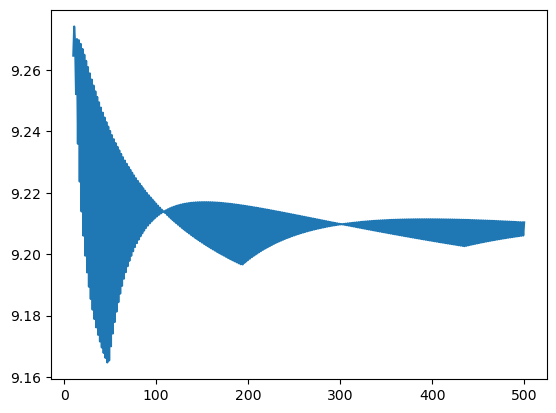

In [18]:
plt.plot(nArray,vArray)

7. Is it possible to store just one time-level? Try to write a code for this.


8. Do you notice any difference (time taken for computation) between the codes with different storage requirements?


9. Try speeding the code up with `numba` or `cython` libraries


## Evaluating Convergence Properties


10. Can you estimate the convergence rate?


11. Assume that the payoff of the option is
$$
V(S,T) = \left\{\begin{array}{cc}
0 & \text{ if } S<X\\
1 & \text{ if } S\geq X
\end{array}\right.
$$
Plot out the solution to this problem with a binomial tree for different value s of $N$, in the case where $S_0=X$ and $S_0\neq X $. Can you explain the results?


In [21]:
no_of_results = 491
S_0 = 100.0
nArray = numpy.zeros(no_of_results)
vArray = numpy.zeros(no_of_results)
for i in range(0,no_of_results):
    n=10+i
    nArray[i] = n
    vArray[i] = binomialBlackScholesV2(S_0,T,r,sigma,lambda S:1.0 if S > X else 0.0,n)

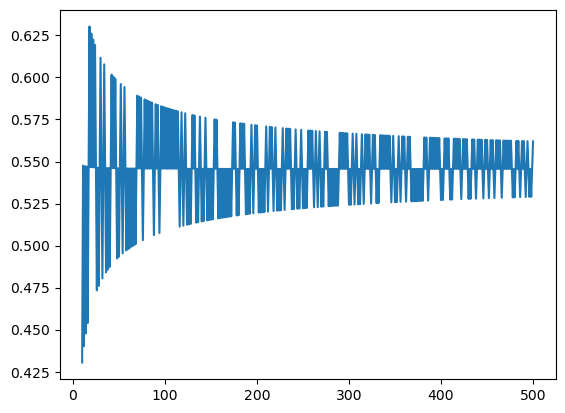

In [22]:
plt.plot(nArray,vArray)

12. Now try setting
$$
V_{n,j} = \left\{\begin{array}{ccc}
0 & \text{ if } &S_j^N<2X - S^N_{j+1}\\
&&\\
\frac{S^N_{j+1} + S^N_j - 2X}{S^N_{j+1}-S^N_{j-1}} & \text{ if } &2X - S^N_{j+1}\leq  S_j^N  \leq 2X-S^N_{j-1} \\
&&\\
1 & \text{ if } &S_j^N > 2X-S^N_{j-1}
\end{array}\right.
$$
and plot the results again. How has it changed? See Heston and Zhou (2000) for more details on how to derive this formula.


In [25]:
def averagePayoff(Sj,X,T,sigma,n):
    dt = T/n
    u = numpy.exp(sigma*numpy.sqrt(dt))
    if Sj < 2*X - u*u*Sj:
        return 0.0
    elif Sj > 2*X - Sj/u/u:
        return 1.0
    else:
        return (u*u*Sj + Sj - 2*X) / (u*u*Sj - Sj/(u*u))

In [28]:
no_of_results = 491
S_0 = 97.153
nArray = numpy.zeros(no_of_results)
vArray = numpy.zeros(no_of_results)
for i in range(0,no_of_results):
    n=10+i
    nArray[i] = n
    vArray[i] = binomialBlackScholesV2(S_0,T,r,sigma,lambda S:averagePayoff(S,X,T,sigma,n),n)

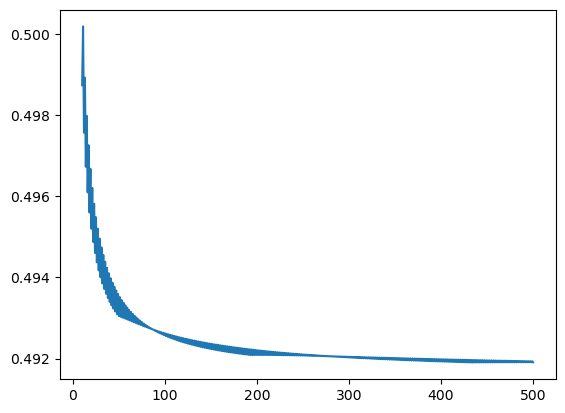

In [29]:
plt.plot(nArray,vArray)